Khai báo và đọc ảnh

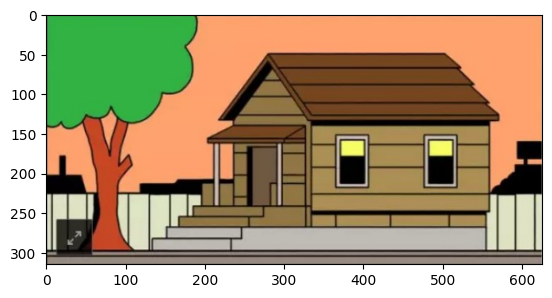

In [35]:
import numpy as np
import cv2
from matplotlib import pyplot as quan

img = cv2.imread('nha.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

quan.imshow(img[:,:,::-1])
quan.show()

2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh. 

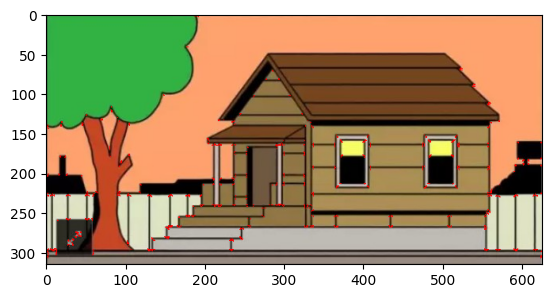

In [36]:
gray_float = np.float32(gray)

dst = cv2.cornerHarris(gray_float,2,3,0.04)

img_harris = img.copy()
img_harris[dst>0.01*dst.max()] = [0,0,255]

quan.imshow(img_harris[:,:,::-1])
quan.show()

3. Sử dụng Band-pass filtering by Difference of Gaussians

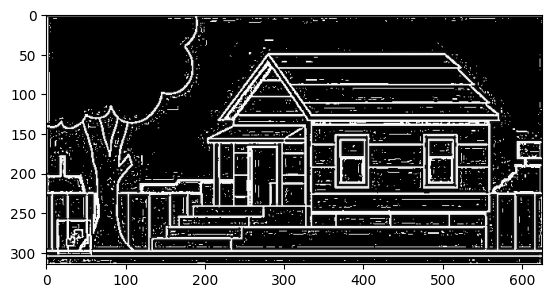

In [37]:
g1 = cv2.GaussianBlur(gray,(5,5),1)
g2 = cv2.GaussianBlur(gray,(5,5),5)

dog = g1 - g2

quan.imshow(dog, cmap='gray')
quan.show()

4. Kiểm tra ảnh qua Automatic Scale Selection 

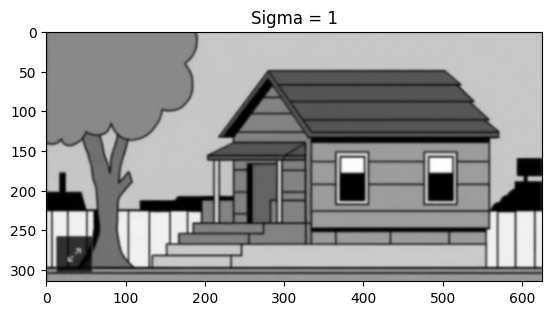

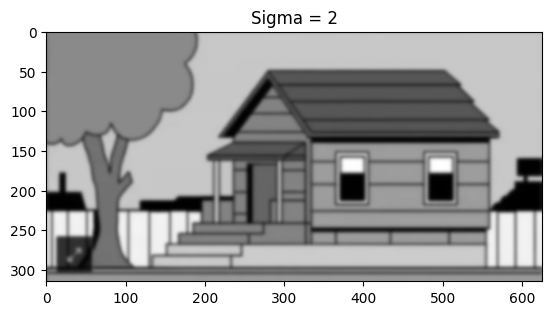

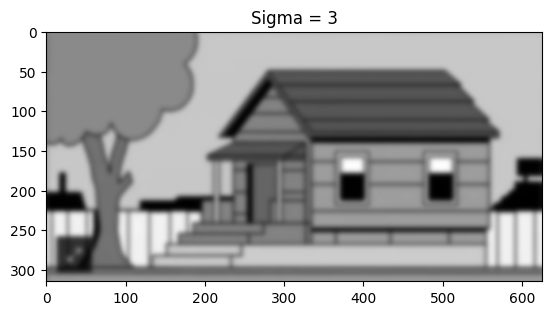

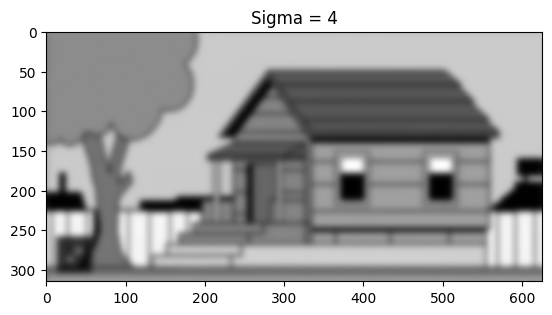

In [38]:
s = [1,2,3,4]

for i in s:
    blur = cv2.GaussianBlur(gray,(0,0),i)
    quan.imshow(blur,cmap='gray')
    quan.title(f"Sigma = {i}")
    quan.show()

5. Kiểm tra ảnh qua Scale Invariant Detection

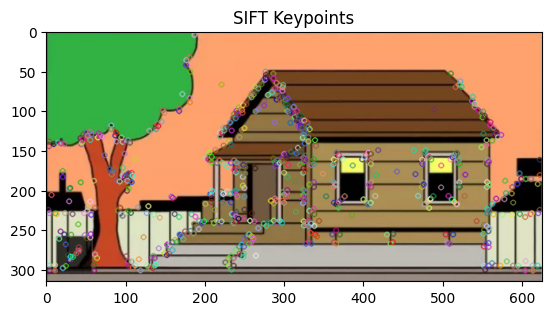

In [39]:
sift = cv2.SIFT_create()

kp = sift.detect(gray,None)

img_sift = cv2.drawKeypoints(img,kp,None)

quan.imshow(img_sift[:,:,::-1])
quan.title("SIFT Keypoints")
quan.show()

6. Kiểm tra ảnh qua Scale-space blob detector. 

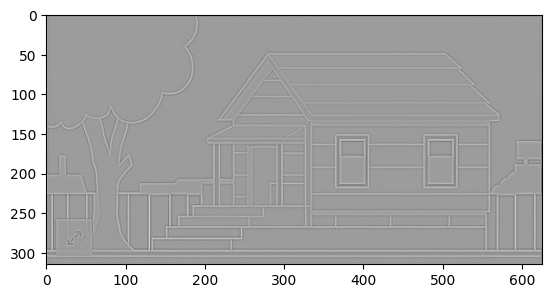

In [40]:
blob = cv2.Laplacian(gray, cv2.CV_64F)

quan.imshow(blob, cmap='gray')
quan.show()

7. Thực hành với Bag-of-words detection

In [41]:
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

# Kmeans tạo vocabulary
Z = np.float32(des)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,1.0)

K = 20
ret,label,center = cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

print("Vocabulary size:",len(center))

Vocabulary size: 20


8. Ghép ảnh Image Panoramas

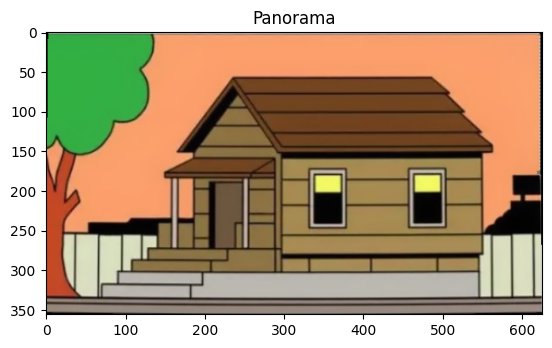

In [43]:
img1 = cv2.imread("nha2.jpg")
img2 = cv2.imread("nha3.jpg")

stitcher = cv2.Stitcher_create()

status,pano = stitcher.stitch([img1,img2])

quan.imshow(pano[:,:,::-1])
quan.title("Panorama")
quan.show()

9. Ghép ảnh Automatic mosaicing 

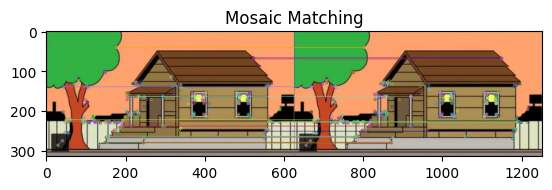

In [ ]:
orb = cv2.ORB_create()

kp1,des1 = orb.detectAndCompute(img1,None)
kp2,des2 = orb.detectAndCompute(img2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.match(des1,des2)

img_match = cv2.drawMatches(img1,kp1,img2,kp2,matches[:20],None)

quan.imshow(img_match[:,:,::-1])
quan.show()

10. Sử dụng Wide base-line stereo

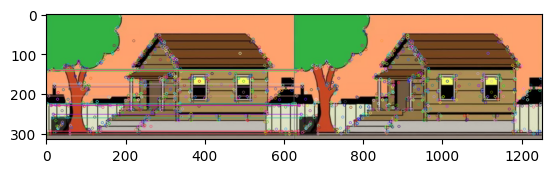

In [ ]:
sift = cv2.SIFT_create()

kp1,des1 = sift.detectAndCompute(img1,None)
kp2,des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good=[]

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

img_stereo = cv2.drawMatches(img1,kp1,img2,kp2,good[:20],None)

quan.imshow(img_stereo[:,:,::-1])
quan.show()

11. CBIR (content-based image retrieval)

nha.jpg similarity: 1.0
nha2.jpg similarity: 0.9877052787082592
nha3.jpg similarity: 0.8799097461112592


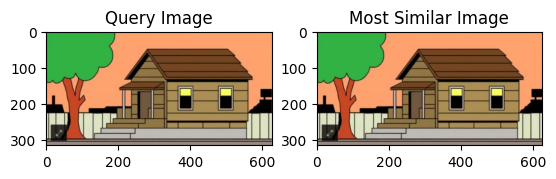

In [45]:
import cv2
import numpy as np
from matplotlib import pyplot as quan

# ảnh query
query = cv2.imread("nha.jpg")

# danh sách ảnh dataset
dataset = ["nha.jpg","nha2.jpg","nha3.jpg"]

# histogram của ảnh query
hist_query = cv2.calcHist([query],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
hist_query = cv2.normalize(hist_query,hist_query)

best_score = -1
best_image = None

for file in dataset:
    
    img = cv2.imread(file)
    
    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
    hist = cv2.normalize(hist,hist)

    score = cv2.compareHist(hist_query,hist,cv2.HISTCMP_CORREL)

    print(file,"similarity:",score)

    if score > best_score:
        best_score = score
        best_image = img

# hiển thị kết quả
quan.subplot(1,2,1)
quan.imshow(query[:,:,::-1])
quan.title("Query Image")

quan.subplot(1,2,2)
quan.imshow(best_image[:,:,::-1])
quan.title("Most Similar Image")

quan.show()

12. Bag-of-word with SIFT + Histogram

BoW Histogram:
[16 51 31 60 26  1 25 55 47 36 79 26 62 43 64 15 14 69 18 37]


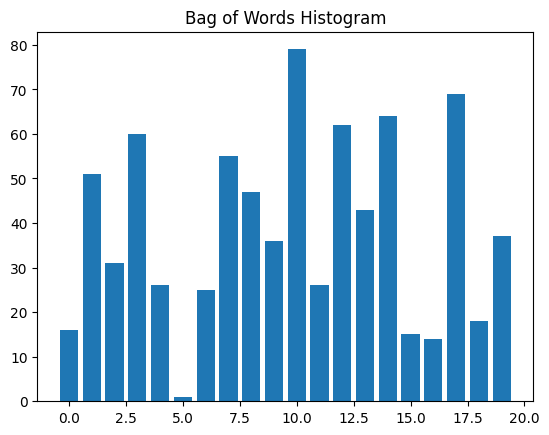

In [46]:
import cv2
import numpy as np
from matplotlib import pyplot as quan

# đọc ảnh
img = cv2.imread("nha.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. SIFT feature
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)

# 2. K-means clustering (tạo visual words)
K = 20
des = np.float32(des)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,1.0)
ret, label, center = cv2.kmeans(des, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# 3. tạo histogram Bag-of-Words
hist = np.bincount(label.flatten(), minlength=K)

print("BoW Histogram:")
print(hist)

# 4. vẽ histogram
quan.bar(range(K), hist)
quan.title("Bag of Words Histogram")
quan.show()